## Objective

An agent learns to **store as few frames as possible** while still reconstructing a
multi-event sequence. It leverages the within-event autoregressive structure to *skip*
predictable frames and *store* at surprises. Keyframes should emerge at event onsets.

Run cells top to bottom. Poke at state between them — that's how you'll actually learn it.

In [1]:
import torch, torch.nn as nn, torch.nn.functional as F
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from utils import plot_style, norm01; plot_style('notebook');

stim_dim = 10     # stim-vector dim
hidden_dim = 64   # hidden dim
recon_wt = 6.0    # weight on reconstruction (too high -> stores all; too low -> stores none)
LR = 1e-4
# seeds
rng = np.random.default_rng(42)
seeds = rng.choice(1000, size=30, replace=False)
train_seeds, test_seeds, eval_seeds = seeds[:20].tolist(), seeds[20:25].tolist(), seeds[25:].tolist()

### Data
Stable features = event **identity** (constant-ish per event); autoreg features = within-event
**trajectory** (OU ramp toward 0 or 1). Variable event lengths. Boundaries come from cumulative
lengths, not fixed spacing.

one video shape (time, features): torch.Size([100, 10])
its boundaries : [ 0 11 21 30 42 54 63 72 83 88]


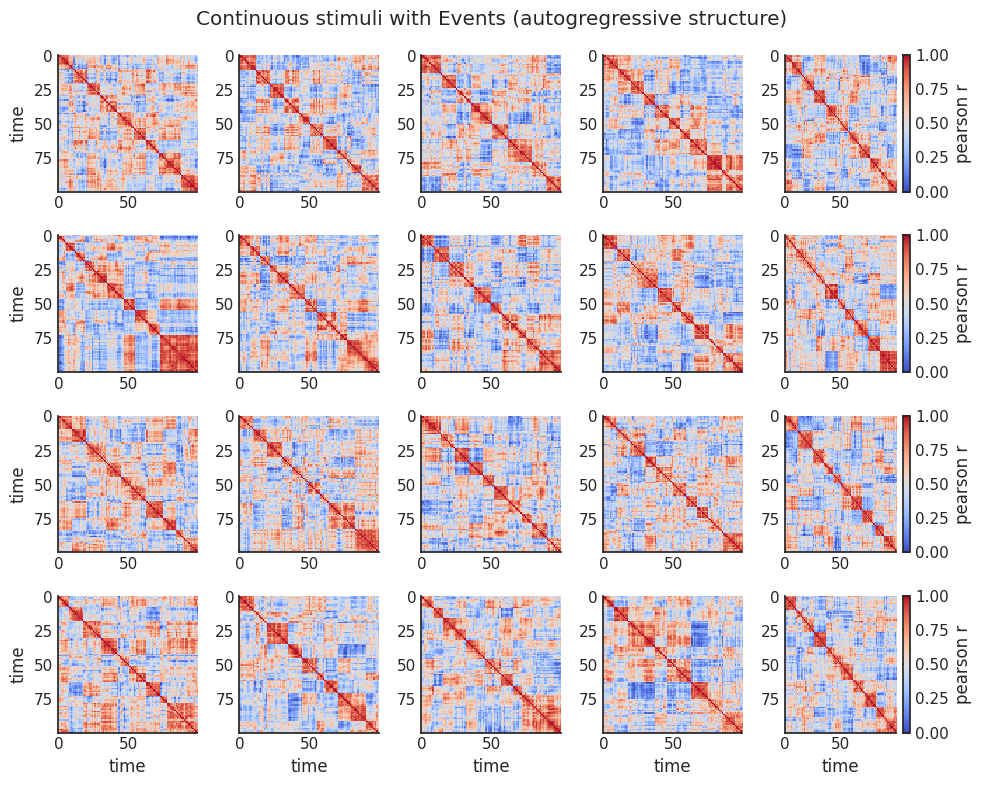

In [2]:
from utils import generate_stim
# returns a dict with keys:stim, event_lengths, event_templates, autoreg_directions, autoreg_features

def stim2tensor(stim): return torch.tensor(stim, dtype=torch.float32)

# fixed train set (each video gets its own structure)
train_data = []
for s in train_seeds:
    stim_info = generate_stim(stim_dim=stim_dim, seed=s)
    train_data.append((stim2tensor(stim_info['stim']), stim_info["event_boundaries"]))
train_stims = [stim for stim, _ in train_data]
print("one video shape (time, features):", train_stims[0].shape)
print("its boundaries :", train_data[0][1])

fig, axs = plt.subplots(4, 5, figsize=(5*2, 4*2))
axs = axs.flatten()
plt.suptitle('Continuous stimuli with Events (autogregressive structure)')
for i, train_stim in enumerate(train_stims):
    axs[i].set(xlabel='time' if i>14 else '', ylabel='time' if i%5==0 else '' )
    im = axs[i].imshow(norm01(np.corrcoef(train_stim.numpy())), aspect='auto', cmap='coolwarm', vmin=0, vmax=1,
                   origin='upper', interpolation='nearest')
    if i in [4, 9, 14, 19]:    plt.colorbar(im, ax=axs[i], label='pearson r')
    plt.tight_layout()
plt.show()

### Forward walk
On **SKIP** the prediction feeds back in (true autoregressive rollout); on **STORE** the
real frame does, resetting drift. Straight-through Gumbel makes the discrete choice trainable.

In [3]:
def forward_walk(stim, predictor, policy, tau=1.0):
    stim_len = stim.shape[0]
    hidden_feats = torch.zeros(hidden_dim)   # GRU hidden state, reset each video
    reconstruction, binarized_keyframes = [], []
    memory_mass = 0.0                         # accumulates soft store decisions for loss

    # initialize first recon_stim and correspond embedding
    recon_stim_t = stim[0]
    _, hidden_feats = predictor.step(recon_stim_t, hidden_feats)
    reconstruction.append(recon_stim_t)

    for t in range(1, stim_len):

        # PREDICT
        # GRU: (x,h) -> h_new
        # Linear: (x,h_new) -> x_new
        y_true = stim[t]
        y_pred, hidden_feats = predictor.step(recon_stim_t, hidden_feats)
        error = F.mse_loss(y_pred, y_true).detach() # should spike at boundaries

        # DECIDE
        logits = decider(y_true, y_pred, error)

        # hard=True keep it discrete for forward pass, while
        #       straight-through simultaneously keeps it continuous for backward pass
        # tau anneals from soft (~0/1) to hard (exactly 0/1) over training
        # gate: vector with [skip, store] probabilities, binarized here bc hard=True
        gate = F.gumbel_softmax(logits, tau=tau, hard=True)
        store = gate[1]

        # UPDATE
        # store is a continuous value here (for gradient flow) but will be 0 or 1 in the forward pass
        recon_stim_t = (store * y_true)   +   ((1 - store) * y_pred)
        reconstruction.append(recon_stim_t)
        memory_mass = memory_mass + store
        binarized_keyframes.append(store.detach().item())

    reconstruction = torch.stack(reconstruction)
    recon_error = F.mse_loss(reconstruction, stim)
    normed_memory_mass = memory_mass / stim_len
    # loss balances sparsity (store few) vs fidelity (reconstruct well)
    loss = normed_memory_mass + recon_wt * recon_error # the thing to minimize
    return reconstruction, loss, memory_mass, binarized_keyframes

### Model: predictor + decider

In [4]:
class Predictor(nn.Module):
    """Given a running hidden state, predict the next frame."""
    def __init__(self):
        super().__init__() 
        self.rnn = nn.GRUCell(stim_dim, hidden_dim) # outputs new hidden state
        self.out = nn.Linear(hidden_dim, stim_dim) # outputs predicted next frame
        
    def step(self, x, h):          # one autoregressive step
        h = self.rnn(x, h)
        return self.out(h), h # return predicted next frame, new hidden state


class Decider(nn.Module):
    """Decide STORE vs SKIP from (actual, predicted, drift)."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential( # run in this order
            nn.Linear(2 * stim_dim + 1, hidden_dim), # actual*predicted + drift=1
            nn.ReLU(),
            nn.Linear(hidden_dim, 2)          # logits: [skip, store]
        )

    def forward(self, actual, pred, drift):
        feat = torch.cat([actual, pred, drift.unsqueeze(0)], dim=-1)
        return self.net(feat)

### Train

In [ ]:
torch.manual_seed(42)
predictor, decider = Predictor(), Decider()
opt = torch.optim.Adam(list(predictor.parameters()) + list(decider.parameters()), lr=LR)

# generate test stims once
test_data = []
for s in test_seeds:
    stim_info = generate_stim(stim_dim=stim_dim, seed=s)
    test_data.append((stim2tensor(stim_info['stim']), stim_info["event_boundaries"]))
test_stims = [stim for stim, _ in test_data]

hist = {"epoch": [], "train_recon_loss": [], "train_memory_mass": [], "train_recon": [],
        "test_recon_loss": [[] for _ in test_seeds], "test_memory_mass": [[] for _ in test_seeds]}
EPOCHS = 100

for epoch in range(EPOCHS):
    epoch_loss = epoch_memory_mass = epoch_reconstruction = 0.0

    tau = max(0.5, 0.95 ** epoch)            # anneal: soft -> sharp

    for stim in train_stims:
        # forward pass
        reconstruction, loss, memory_mass, _ = forward_walk(stim, predictor, decider, tau=tau)
        # clear old gradients, backprop, and update weights
        opt.zero_grad(); loss.backward(); opt.step()
        # increment across stims
        epoch_loss += loss.item()
        epoch_memory_mass += memory_mass.item()
        epoch_reconstruction += F.mse_loss(reconstruction, stim).item()

    # append epoch results
    hist["epoch"].append(epoch)
    hist["train_recon_loss"].append(epoch_loss/len(train_stims))
    hist["train_memory_mass"].append(epoch_memory_mass/len(train_stims))
    hist["train_recon"].append(epoch_reconstruction/len(train_stims))

    # evaluate on all test stims (no gradient)
    with torch.no_grad():
        for i, ts in enumerate(test_stims):
            recon, _, mem_mass, _ = forward_walk(ts, predictor, decider, tau=tau)
            hist["test_recon_loss"][i].append(F.mse_loss(recon, ts).item())
            hist["test_memory_mass"][i].append(mem_mass.item())

### Visual inspection
keyframes should succeed boundaries

In [6]:
eval_results = []
with torch.no_grad():
    for s in eval_seeds:
        info = generate_stim(stim_dim=stim_dim, seed=s)
        stim_t = stim2tensor(info['stim'])
        _, _, _, bkf = forward_walk(stim_t, predictor, decider, tau=0.5)
        kf = [0] + [i + 1 for i, g in enumerate(bkf) if g > 0.5]
        eval_results.append((stim_t, info['event_boundaries'], bkf, kf))

### Plots

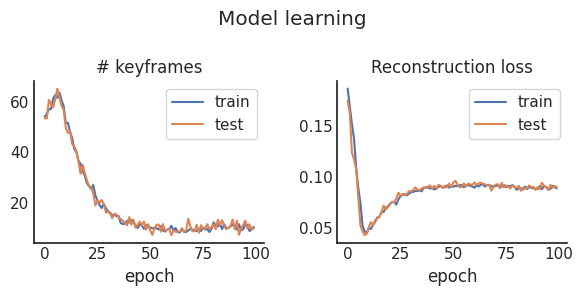

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(6, 3))
plt.suptitle('Model learning')

avg_test_mass = np.mean(hist["test_memory_mass"], axis=0)
avg_test_recon = np.mean(hist["test_recon_loss"], axis=0)

ax[0].set(title='# keyframes', xlabel='epoch')
ax[0].plot(hist["epoch"], hist["train_memory_mass"], label='train')
ax[0].plot(hist["epoch"], avg_test_mass, label='test')
ax[0].legend()

ax[1].set(title="Reconstruction loss", xlabel='epoch')
ax[1].plot(hist["epoch"], hist["train_recon"], label='train')
ax[1].plot(hist["epoch"], avg_test_recon, label='test')
ax[1].legend()

plt.tight_layout(); plt.show()

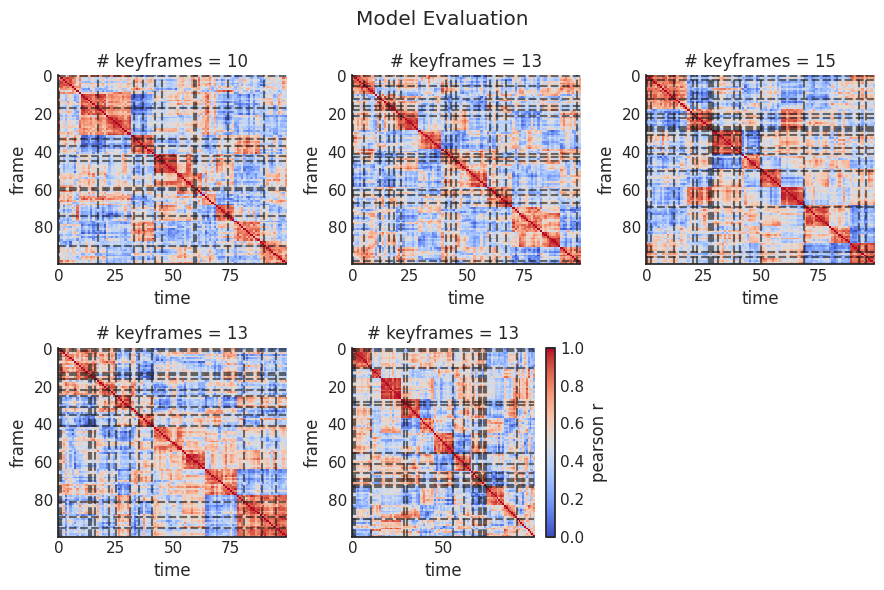

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(3*3, 2*3))
plt.suptitle('Model Evaluation')
for ax, (stim_t, boundaries, _, keyframes) in zip(axes.flatten(), eval_results):
    ax.set(title = f"# keyframes = {len(keyframes)}")
    im = ax.imshow(norm01(np.corrcoef(stim_t.numpy())), aspect='auto', cmap='coolwarm',
                   vmin=0, vmax=1, origin='upper', interpolation='nearest')
    for kf in keyframes:
        ax.axvline(kf, color="k", linestyle="--", alpha=0.6)
        ax.axhline(kf, color="k", linestyle="--", alpha=0.6)
    ax.set(xlabel="time", ylabel="frame")
axes.flatten()[-1].set_visible(False)
plt.colorbar(im, ax=axes[1, -2], label="pearson r")
plt.tight_layout(); plt.show()

### Jaccard's/Hamming test

In [ ]:
def jaccard(boundaries, keyframes, T, tol):
    """Dilate both sets by ±tol frames, then compute |B∩K| / |B∪K|."""
    b_mask, k_mask = np.zeros(T, dtype=bool), np.zeros(T, dtype=bool)
    # dilate
    for b in boundaries:    b_mask[max(0, b - tol):min(T, b + tol + 1)] = True
    for k in keyframes:     k_mask[max(0, k - tol):min(T, k + tol + 1)] = True
    intersection, union = (b_mask & k_mask).sum(), (b_mask | k_mask).sum()
    return intersection / union if union > 0 else 0.0

stim_data = [(boundaries, kf, stim_t.shape[0]) for stim_t, boundaries, _, kf in eval_results]

N_PERM = 1000
tolerances = [0, 1, 2, 3, 5]
perm_jaccards = {tol: [] for tol in tolerances}

np.random.seed(42)
for _ in range(N_PERM):
    for tolerance in tolerances:
        perm_jaccards[tolerance].append(
            np.mean([jaccard(bound, np.random.choice(T, size=len(key), replace=False), T, tolerance)
                     for bound, key, T in stim_data]))

print(f"n stims = {len(stim_data)}")
print(f"{'tolerance':>4}  {'Jaccard':>8}  {'perm mean':>10}  {'p-value':>8}")
print("-" * 38)
for tol in tolerances:
    j = np.mean([jaccard(b, k, T, tol) for b, k, T in stim_data])
    null = np.array(perm_jaccards[tol])
    p = (null >= j).mean()
    print(f"{tol:>4}  {j:>8.3f}  {null.mean():>10.3f}  {p:>8.3f}")

n stims = 5
tolerance   Jaccard   perm mean   p-value
--------------------------------------
   0     0.131       0.063     0.006
   1     0.229       0.186     0.073
   2     0.331       0.327     0.431
   3     0.435       0.471     0.879
   5     0.659       0.727     0.968


### Things to try
* Plot correlation between true & pred across time
* Plot #keyframes vs. event length

* vary lambda (1 vs 30 for example)
* Replace the predictor with **persistence** (`pred = cur`) as a control — does it still find boundaries?
* Track rollout error at the mid-event extra keyframes — meaningful drift, or noise?